# Predicting Student Career Readiness in the Age of AI 

## Project Overview

This project explores how students' AI usage, study habits, stress levels, motivation, and career anxiety relate to their overall career readiness. The target variable is `overall_career_readiness_score`, predicted as a regression task.

The workflow includes:

1. Data Loading
2. Data Cleaning
3. Outlier Detection
4. Descriptive Statistics        
5. Exploratory Data Analysis (EDA)
6. Feature Engineering
7. Machine Learning Modeling and Model Evaluation

##### **SECTION 1 -  DATA LOADING**

In [154]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import shap

from scipy.stats import gaussian_kde
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [155]:
# load the dataset and display first five rows
student_df = pd.read_csv("data/ai_dependency_career_anxiety_students.csv")

print("Shape:", student_df.shape)
print(student_df.head())

Shape: (15000, 30)
  student_id  age  gender  degree_type                stream  year_of_study  \
0  STU_00001   25    Male  B.Tech/B.E.  Engineering (Non-CS)              3   
1  STU_00002   20  Female  B.Tech/B.E.  Engineering (Non-CS)              4   
2  STU_00003   25  Female          MBA                 CS/IT              1   
3  STU_00004   23    Male  B.Tech/B.E.                 CS/IT              1   
4  STU_00005   22  Female          MBA                 CS/IT              1   

  college_tier urban_or_rural  daily_ai_tool_usage_hrs primary_ai_tools_used  \
0       Tier 3          Rural                      0.3            Perplexity   
1       Tier 3          Urban                      1.9               ChatGPT   
2       Tier 3          Urban                      3.6                Gemini   
3       Tier 1          Urban                      4.1        GitHub Copilot   
4       Tier 1          Urban                      3.4               ChatGPT   

   ... daily_study_hours 

In [156]:
# student_id is a unique identifier with no predictive value
student_df = student_df.drop(columns=["student_id"])

print("student_id dropped.")
print("New shape:", student_df.shape)

student_id dropped.
New shape: (15000, 29)


In [157]:
# inspecting data types and null counts
student_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 29 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              15000 non-null  int64  
 1   gender                           15000 non-null  object 
 2   degree_type                      15000 non-null  object 
 3   stream                           15000 non-null  object 
 4   year_of_study                    15000 non-null  int64  
 5   college_tier                     15000 non-null  object 
 6   urban_or_rural                   15000 non-null  object 
 7   daily_ai_tool_usage_hrs          15000 non-null  float64
 8   primary_ai_tools_used            11785 non-null  object 
 9   uses_ai_for_assignments          15000 non-null  object 
 10  ai_replaces_own_thinking_score   15000 non-null  int64  
 11  ai_dependency_score              15000 non-null  int64  
 12  placement_anxiety_

In [158]:
# checking missing values
print(student_df.isnull().sum())

age                                   0
gender                                0
degree_type                           0
stream                                0
year_of_study                         0
college_tier                          0
urban_or_rural                        0
daily_ai_tool_usage_hrs               0
primary_ai_tools_used              3215
uses_ai_for_assignments               0
ai_replaces_own_thinking_score        0
ai_dependency_score                   0
placement_anxiety_score               0
fear_of_job_loss_to_ai                0
career_clarity_score                  0
internship_experience                 0
weekly_job_application_count          0
resume_confidence_score               0
interview_anxiety_score               0
daily_study_hours                     0
self_learning_hours_per_week        233
skill_development_courses_taken       0
social_media_hrs_per_day            210
sleep_hours                         203
stress_level                          0


##### **SECTION 2 - DATA CLEANING**

In [159]:
# categorical column: filling with mode (most frequent value)
student_df["primary_ai_tools_used"] = student_df["primary_ai_tools_used"].fillna(
    student_df["primary_ai_tools_used"].mode()[0]
)
 
# continuous numerical columns: filling with median
for col in ["self_learning_hours_per_week", "social_media_hrs_per_day", "sleep_hours"]:
    student_df[col] = student_df[col].fillna(student_df[col].median())
 
# binary column (0/1): filling with mode
student_df["seeks_career_counseling"] = student_df["seeks_career_counseling"].fillna(
    student_df["seeks_career_counseling"].mode()[0]
)
 
print("Missing values have been handled.")
print()
 
# verify no missing values remain
print(student_df.isnull().sum())

Missing values have been handled.

age                                0
gender                             0
degree_type                        0
stream                             0
year_of_study                      0
college_tier                       0
urban_or_rural                     0
daily_ai_tool_usage_hrs            0
primary_ai_tools_used              0
uses_ai_for_assignments            0
ai_replaces_own_thinking_score     0
ai_dependency_score                0
placement_anxiety_score            0
fear_of_job_loss_to_ai             0
career_clarity_score               0
internship_experience              0
weekly_job_application_count       0
resume_confidence_score            0
interview_anxiety_score            0
daily_study_hours                  0
self_learning_hours_per_week       0
skill_development_courses_taken    0
social_media_hrs_per_day           0
sleep_hours                        0
stress_level                       0
burnout_score                      0
mot

In [160]:
# checking how many duplicate rows exist
print("Number of duplicate rows:", student_df.duplicated().sum())

Number of duplicate rows: 0


##### **OUTLIER DETECTION (IQR METHOD)**

In [161]:
# outlier detection using IQR method

# selecting only numeric columns
numeric_cols = student_df.select_dtypes(include=["int64", "float64"]).columns

outlier_summary = []

for col in numeric_cols:
    Q1 = student_df[col].quantile(0.25)
    Q3 = student_df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outlier_count = student_df[
        (student_df[col] < lower_bound) | (student_df[col] > upper_bound)
    ].shape[0]
    
    outlier_summary.append({
        "Column": col,
        "Outlier_Count": outlier_count,
        "Lower_Bound": lower_bound,
        "Upper_Bound": upper_bound
    })

outlier_df = pd.DataFrame(outlier_summary)

print(outlier_df)

                             Column  Outlier_Count  Lower_Bound  Upper_Bound
0                               age            606        17.00        25.00
1                     year_of_study              0        -2.00         6.00
2           daily_ai_tool_usage_hrs             41        -3.80         7.40
3    ai_replaces_own_thinking_score              0        -1.00         7.00
4               ai_dependency_score              0        -1.50        10.50
5           placement_anxiety_score              0        -2.00        14.00
6            fear_of_job_loss_to_ai              0         0.00         8.00
7              career_clarity_score              0        -1.50        10.50
8             internship_experience            809        -0.50         3.50
9      weekly_job_application_count             56        -7.50        28.50
10          resume_confidence_score              0        -1.00         7.00
11          interview_anxiety_score              0        -2.00        14.00

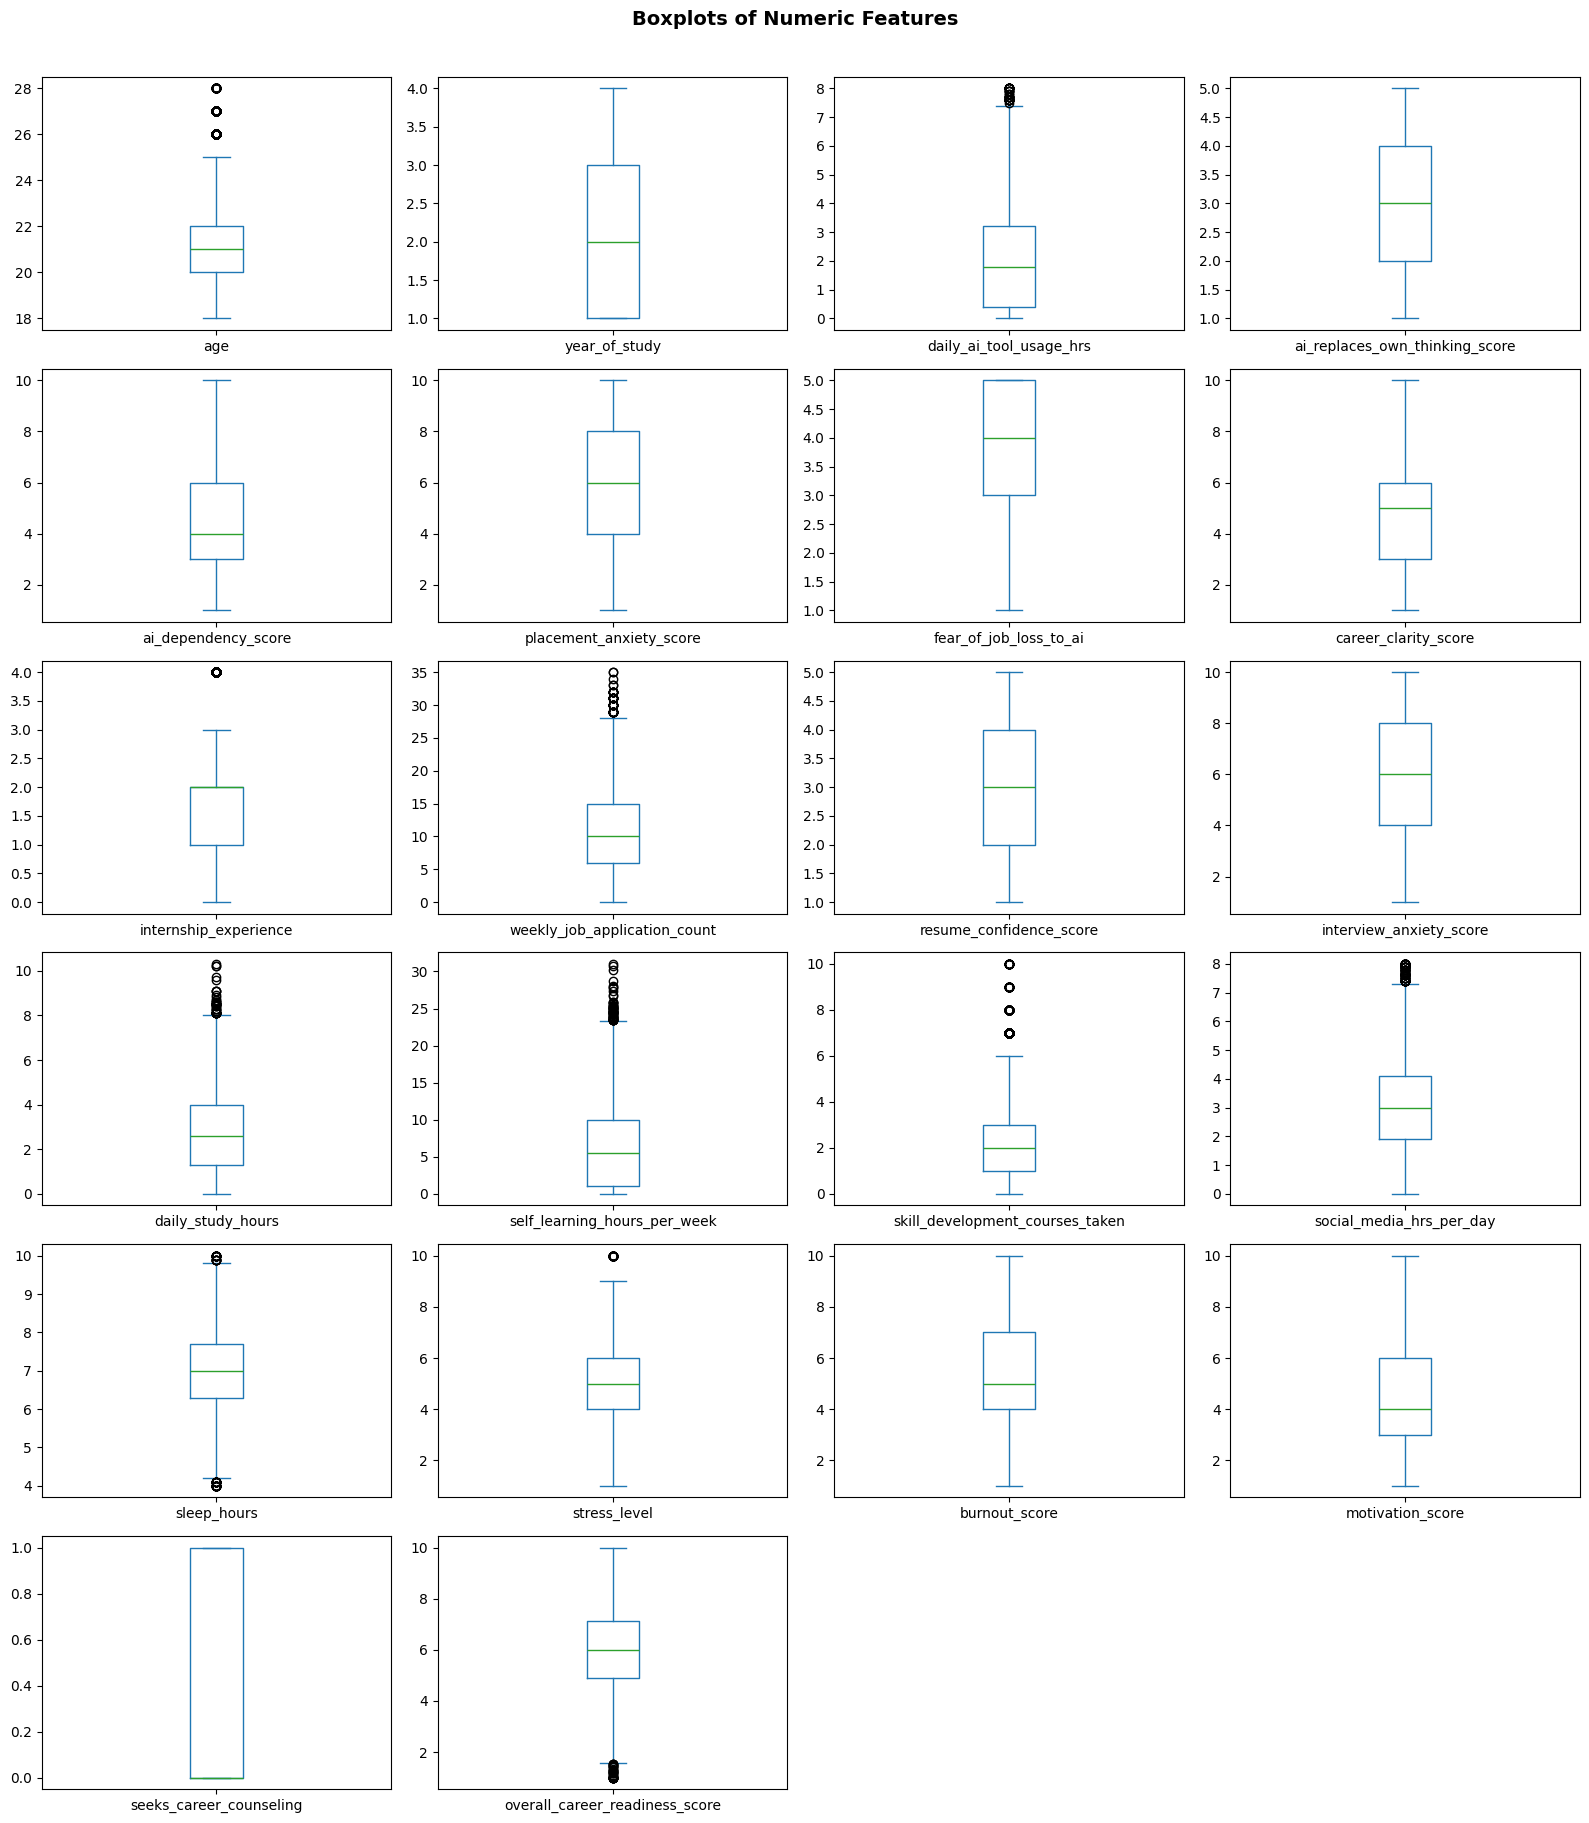

In [162]:
# creating boxplots showing outlier 

numeric_cols = student_df.select_dtypes(include=["int64", "float64"]).columns

student_df[numeric_cols].plot(
    kind="box",
    subplots=True,
    layout=(6,4),
    figsize=(16,18),
    sharex=False,
    sharey=False
)

plt.suptitle("Boxplots of Numeric Features", y=1.01, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

Outlier Detection Summary
--------------------------
Outliers were identified using the IQR method and visualized with boxplots.
Flagged variables and decisions:
 
  - age (n=606)                        : Students aged 26-28 are plausible
                                         postgraduate or returning students.
  - daily_ai_tool_usage_hrs (n=41)     : High usage is realistic for heavy AI users.
  - weekly_job_application_count (n=56): Upper-range values reflect active job seekers.
  - self_learning_hours_per_week (n=56): Outliers reflect motivated self-learners.
  - overall_career_readiness_score(n=31): Extreme low scores are within valid range.
 
All outliers were retained as they represent plausible student behaviors,
not data entry errors.

**DESCRIPTIVE STATISTICS**

In [163]:
# summary statistics for all columns
print("=== Full Summary ===")
summary = student_df.describe(include="all").T
print(summary)

# summary statistics for numerical features only
print("=== Numerical Features ===")
print(student_df.describe())
 
# summary statistics for categorical features only
print("=== Categorical Features ===")
print(student_df.describe(include="object"))

=== Full Summary ===
                                   count unique          top   freq  \
age                              15000.0    NaN          NaN    NaN   
gender                             15000      3         Male   7840   
degree_type                        15000      4  B.Tech/B.E.   6700   
stream                             15000      4        CS/IT   6091   
year_of_study                    15000.0    NaN          NaN    NaN   
college_tier                       15000      3       Tier 3   7475   
urban_or_rural                     15000      2        Urban  10282   
daily_ai_tool_usage_hrs          15000.0    NaN          NaN    NaN   
primary_ai_tools_used              15000      5      ChatGPT   8684   
uses_ai_for_assignments            15000      5        Never   4603   
ai_replaces_own_thinking_score   15000.0    NaN          NaN    NaN   
ai_dependency_score              15000.0    NaN          NaN    NaN   
placement_anxiety_score          15000.0    NaN         

Descriptive Statistics Summary
--------------------------------
 The dataset contains 15,000 student records across 30 variables covering
demographic information, AI usage, academic behavior, career anxiety,
and career readiness. After removing the unique student_id field, 29 variables were retained for analysis, including 28 predictors and one target variable.
 
Key observations:
  - Median age is 21 (range: 18-28).
  - Most common degree: B.Tech/B.E. in the CS/IT stream.
  - Most used AI tool: ChatGPT.
  - Median career readiness score: 6.0 (scale: 1-10), indicating moderate
    readiness across the sample.
  - Variables such as AI usage, study hours, stress, burnout, and motivation
    show strong variability, making them suitable predictors for modeling.

##### **SECTION 5 - EDA (EXPLORATORY DATA ANALYSIS)**

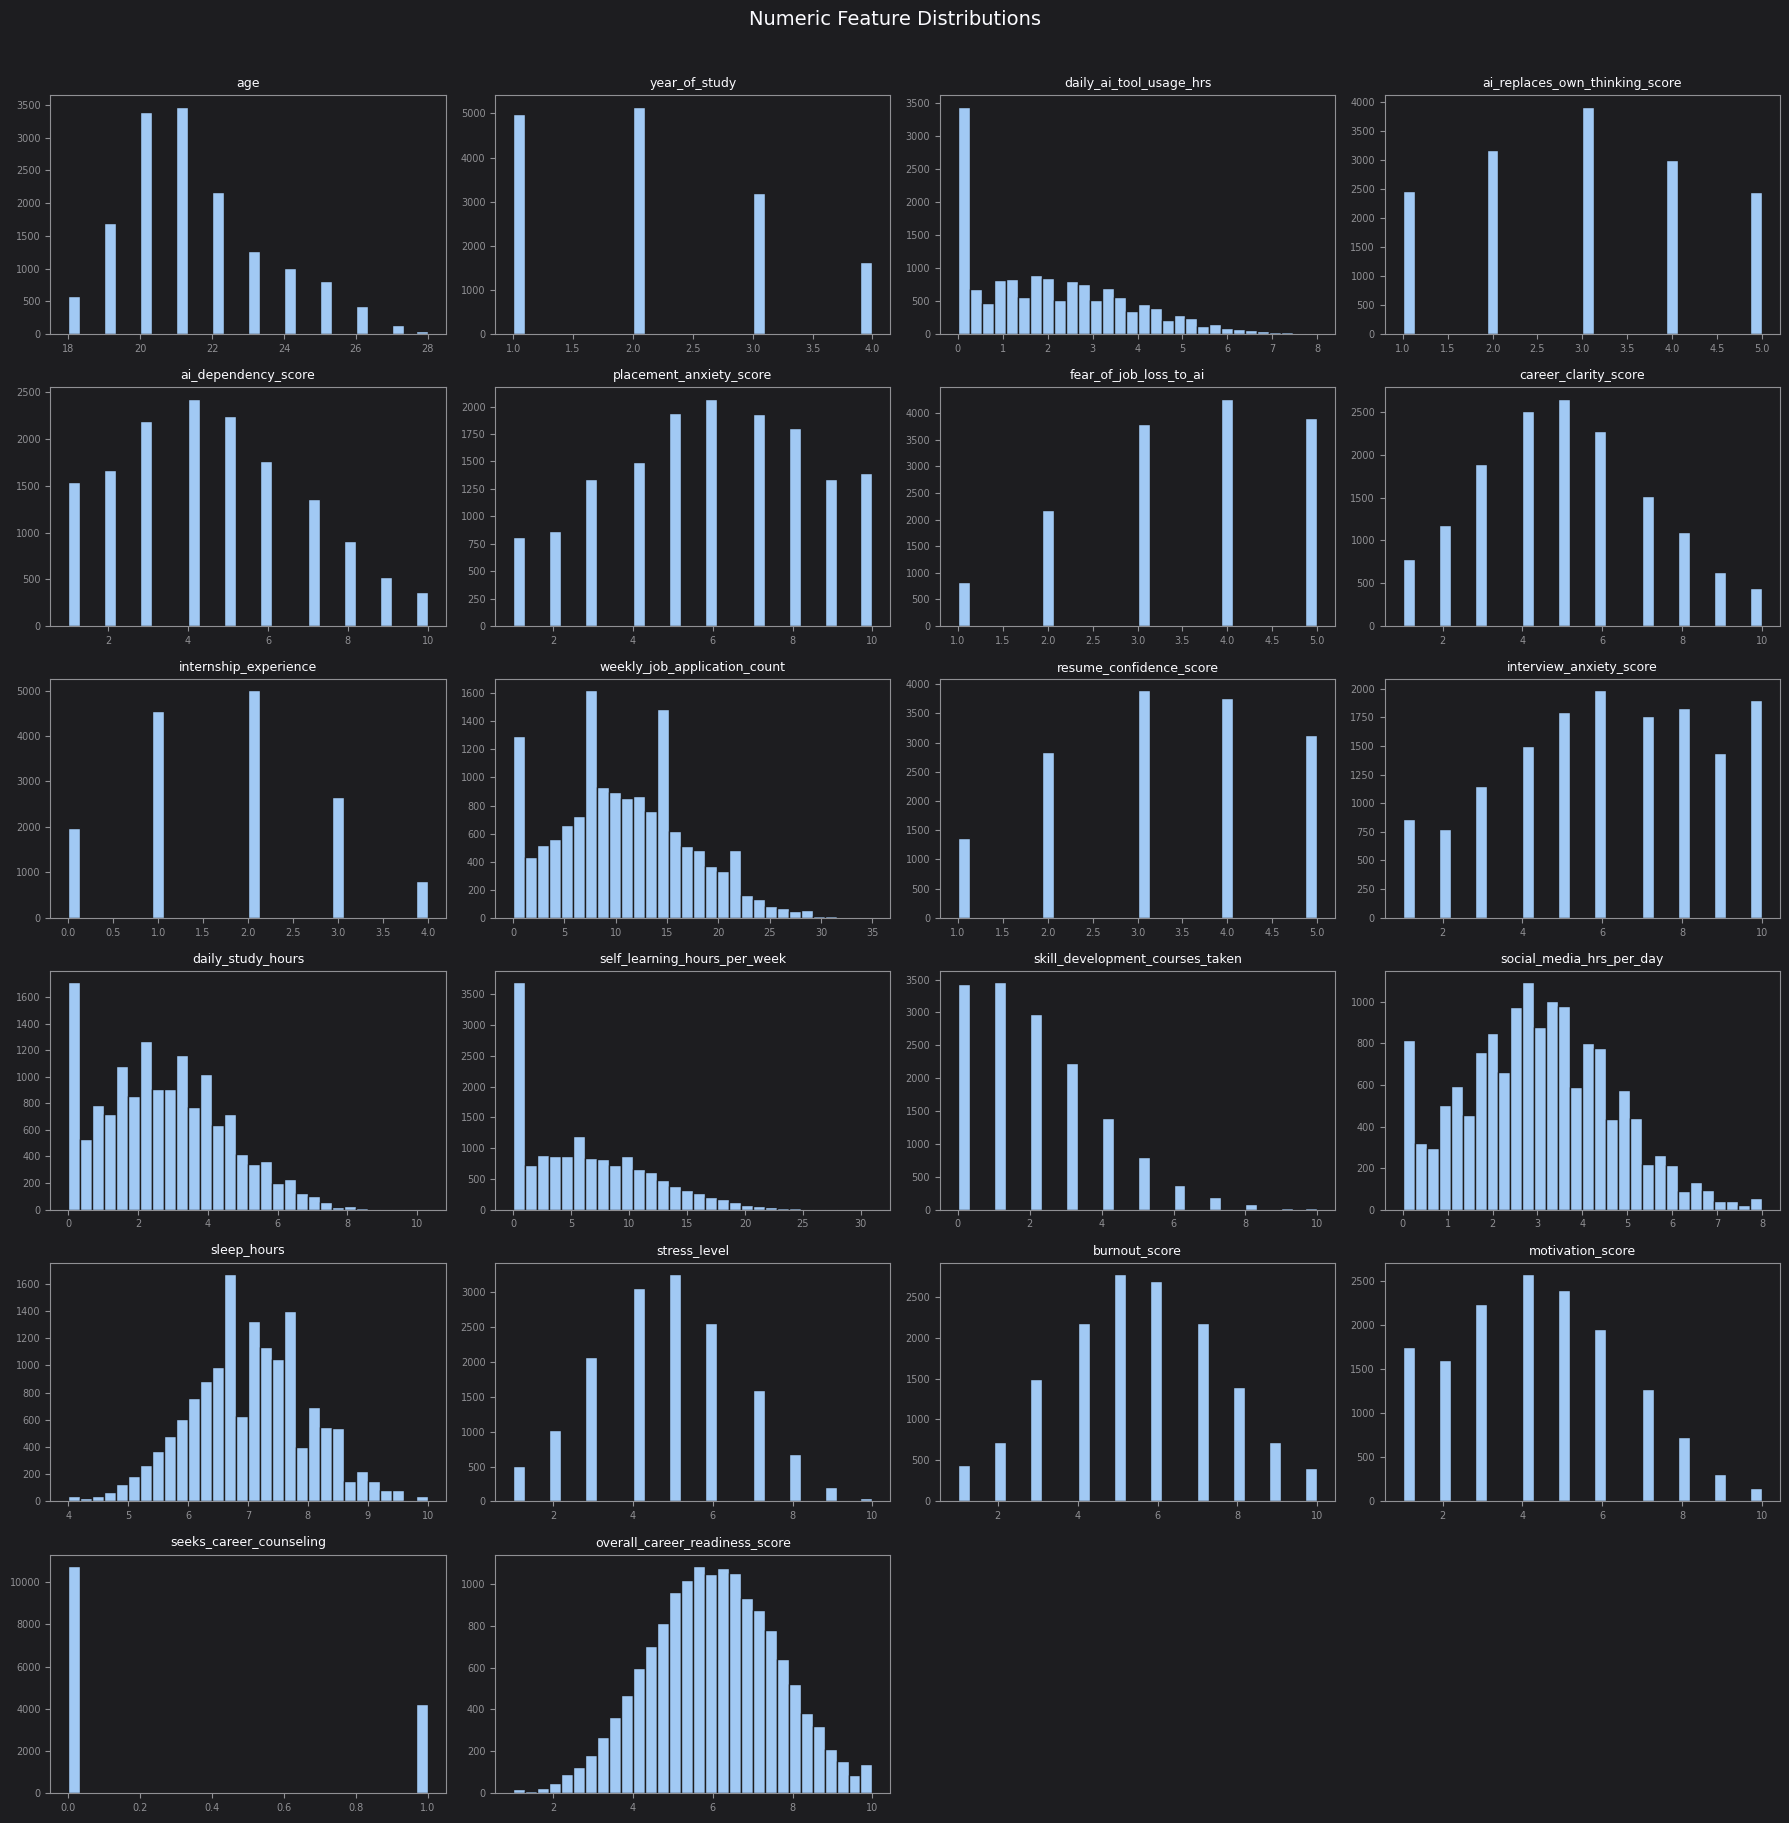

In [164]:
numeric_cols = student_df.select_dtypes(include='number').columns
n_cols = 4
n_rows = -(-len(numeric_cols) // n_cols)  # ceiling division
 
hist_fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3))
axes = axes.flatten()
 
for i, col in enumerate(numeric_cols):
    axes[i].hist(student_df[col].dropna(), bins=30, color='#A1C9F4', edgecolor='#1D1D20')
    axes[i].set_title(col, color='#fbfbff', fontsize=9)
    axes[i].set_facecolor('#1D1D20')
    axes[i].tick_params(colors='#909094', labelsize=7)
    for spine in axes[i].spines.values():
        spine.set_edgecolor('#909094')
 
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
 
hist_fig.patch.set_facecolor('#1D1D20')
hist_fig.suptitle('Numeric Feature Distributions', color='#fbfbff', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**CORRELATION HEATMAP**

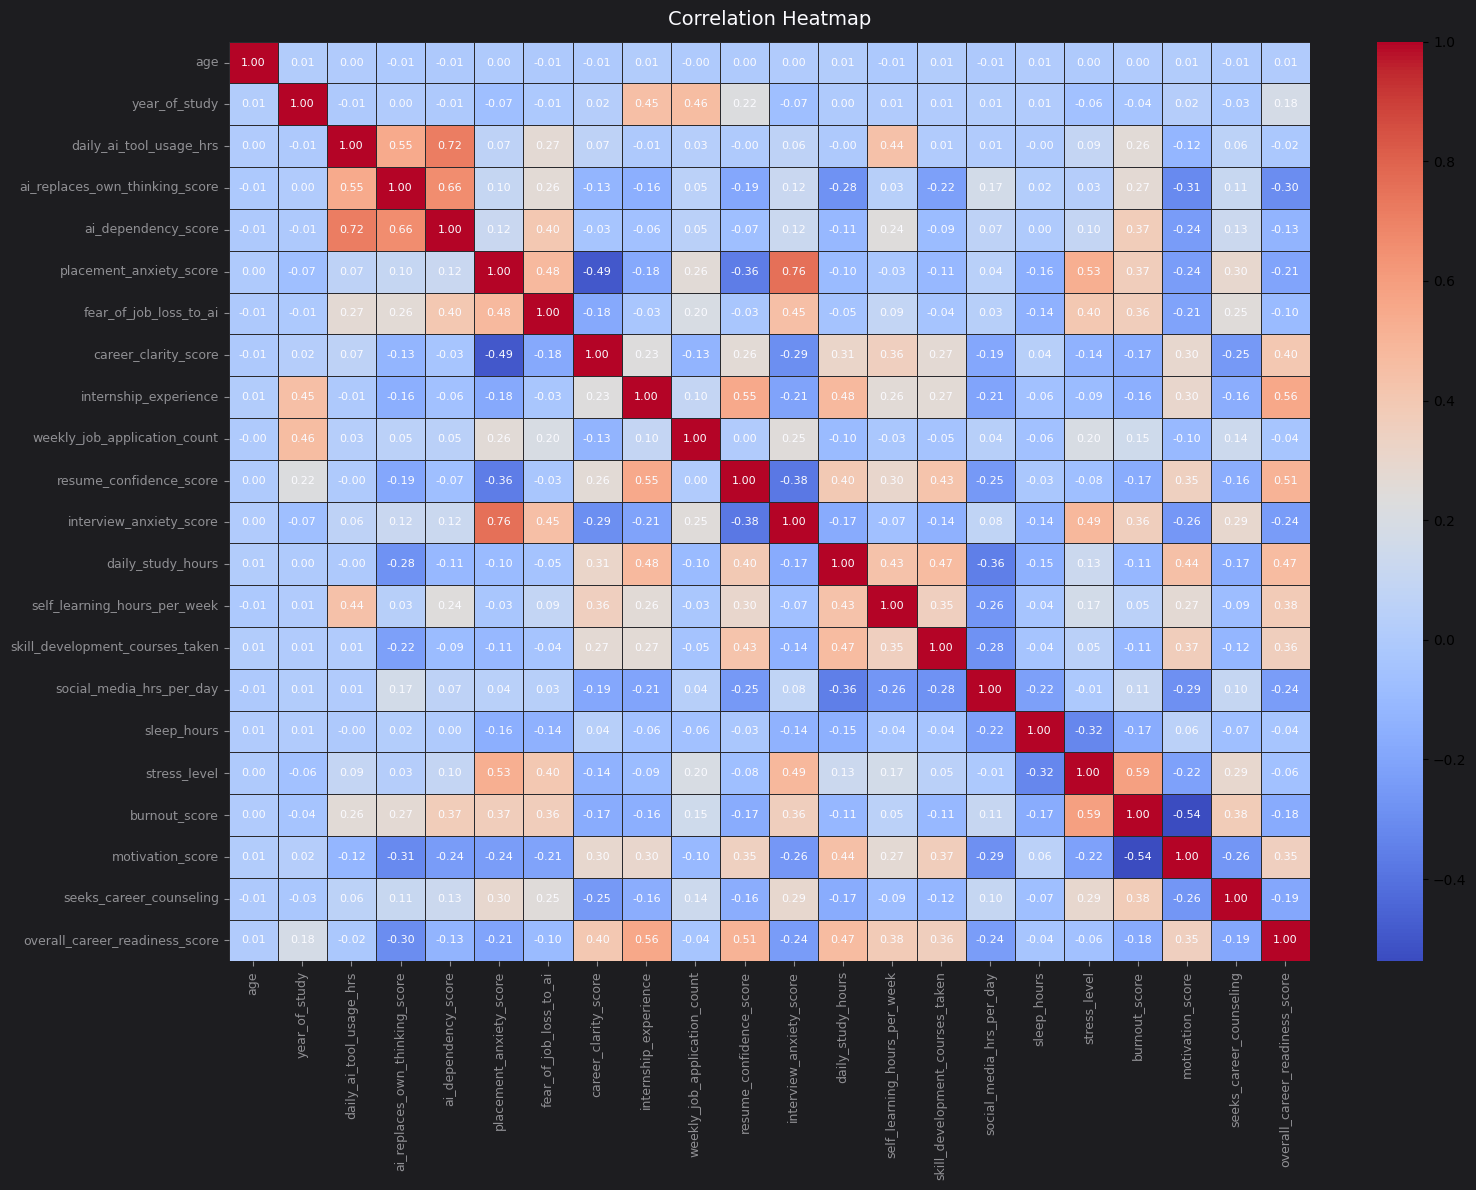

In [165]:
_corr = student_df.select_dtypes(include=np.number).corr()

corr_heatmap, ax = plt.subplots(figsize=(16, 12))
corr_heatmap.patch.set_facecolor("#1D1D20")
ax.set_facecolor("#1D1D20")

sns.heatmap(
    _corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    linecolor="#2a2a2e",
    annot_kws={"size": 8, "color": "#fbfbff"},
    ax=ax
)

ax.set_title("Correlation Heatmap", color="#fbfbff", fontsize=14, pad=12)
ax.tick_params(colors="#909094", labelsize=9)
for spine in ax.spines.values():
    spine.set_edgecolor("#2a2a2e")

plt.tight_layout()
plt.show()

**TARGET VARIABLE DISTRIBUTION**

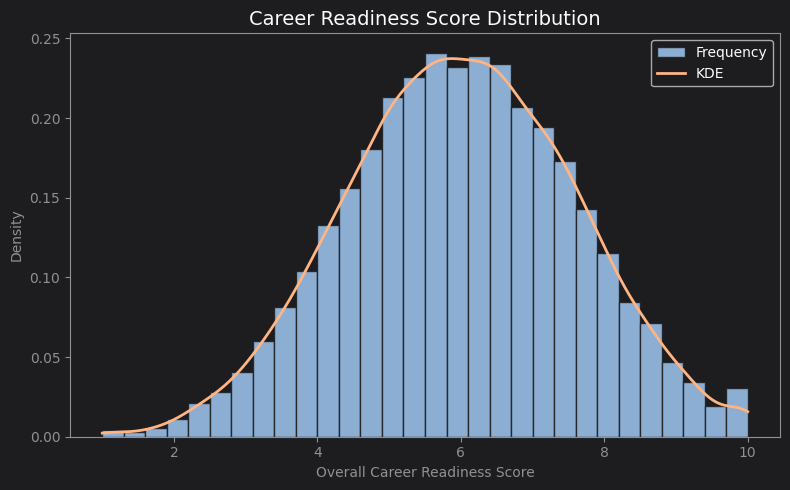

In [166]:
scores = student_df["overall_career_readiness_score"].dropna().values

fig_target_dist, ax = plt.subplots(figsize=(8, 5))
fig_target_dist.patch.set_facecolor("#1D1D20")
ax.set_facecolor("#1D1D20")

ax.hist(scores, bins=30, color="#A1C9F4", edgecolor="#1D1D20",
        alpha=0.85, density=True, label="Frequency")

_kde = gaussian_kde(scores)
_x = np.linspace(scores.min(), scores.max(), 300)
ax.plot(_x, _kde(_x), color="#FFB482", linewidth=2, label="KDE")

ax.set_title("Career Readiness Score Distribution", color="#fbfbff", fontsize=14)
ax.set_xlabel("Overall Career Readiness Score", color="#909094")
ax.set_ylabel("Density", color="#909094")
ax.tick_params(colors="#909094")
ax.legend(facecolor="#1D1D20", labelcolor="#fbfbff")
for spine in ax.spines.values():
    spine.set_edgecolor("#909094")

plt.tight_layout()
plt.show()

**CORRELATION WITH TARGET VARIABLE**

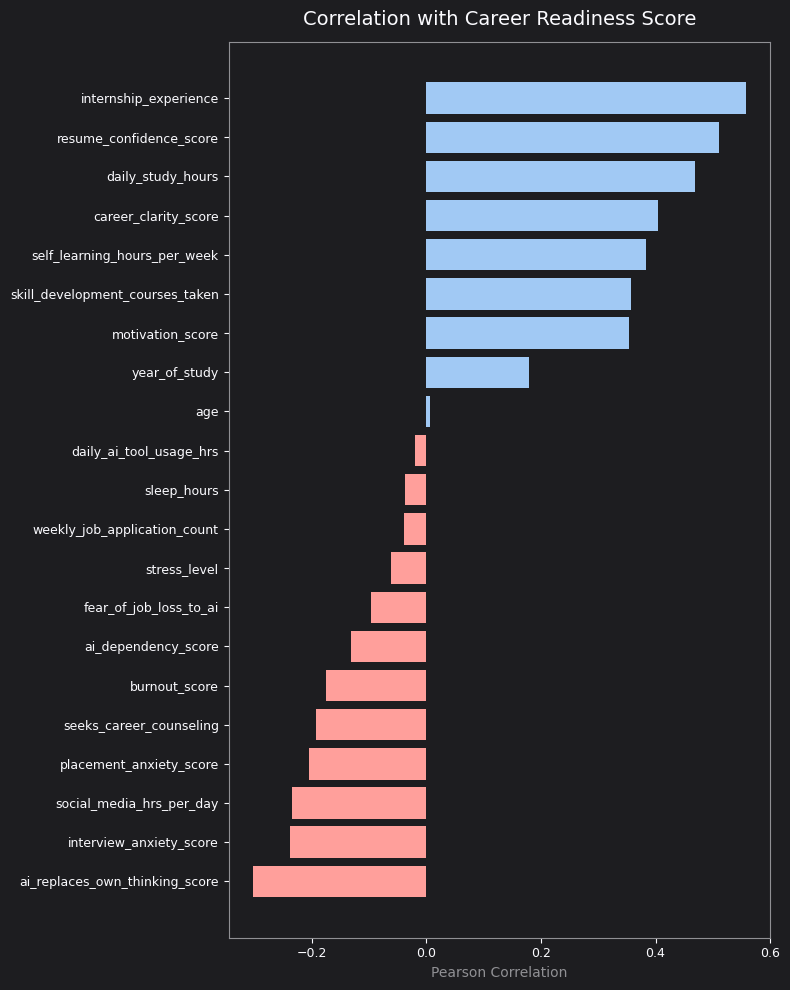

In [167]:
target_corr = (
    student_df.select_dtypes(include=np.number)
    .corr()["overall_career_readiness_score"]
    .drop("overall_career_readiness_score")
    .sort_values()
)
 
colors = ["#FF9F9B" if v < 0 else "#A1C9F4" for v in target_corr]
 
fig_corr_target, ax = plt.subplots(figsize=(8, 10))
fig_corr_target.patch.set_facecolor("#1D1D20")
ax.set_facecolor("#1D1D20")
 
ax.barh(target_corr.index, target_corr.values, color=colors)
ax.set_title("Correlation with Career Readiness Score", color="#fbfbff", fontsize=14, pad=12)
ax.set_xlabel("Pearson Correlation", color="#909094")
ax.tick_params(colors="#fbfbff", labelsize=9)
for spine in ax.spines.values():
    spine.set_edgecolor("#909094")
 
plt.tight_layout()
plt.show()

**PAIRPLOT (MOST IMPORTANT VARIABLES)**

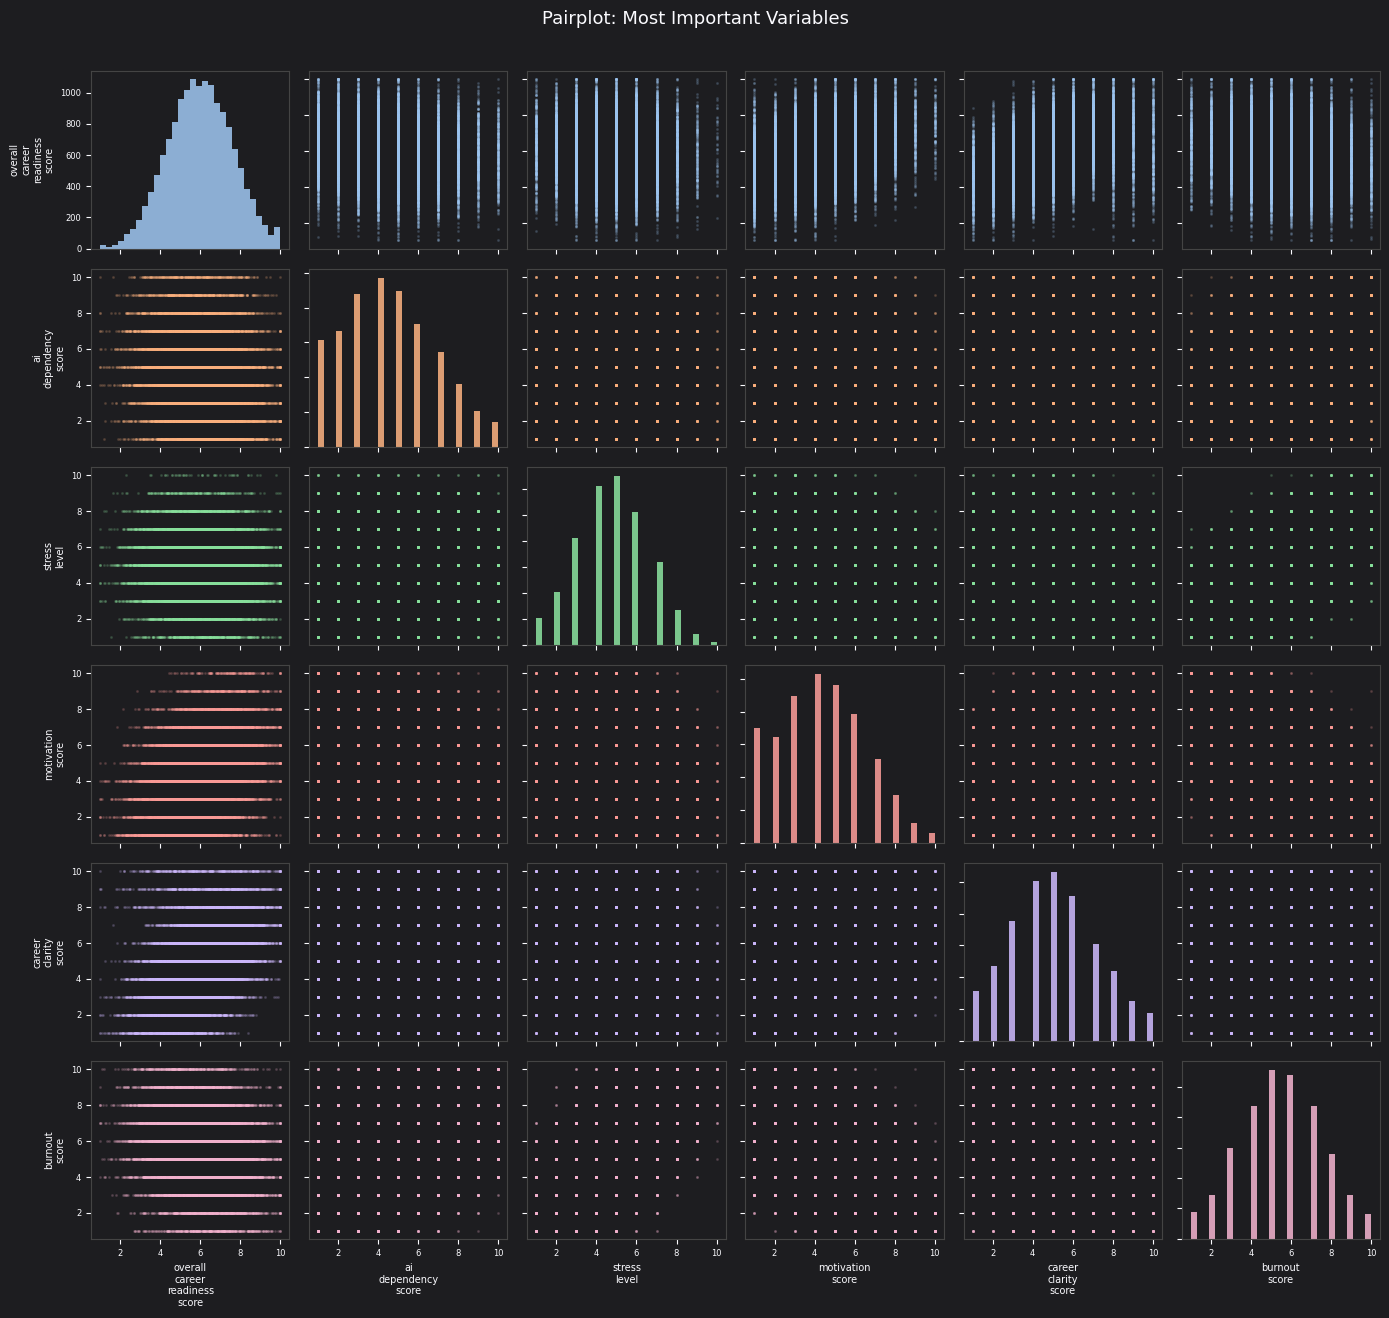

In [168]:
important = [
    "overall_career_readiness_score",
    "ai_dependency_score",
    "stress_level",
    "motivation_score",
    "career_clarity_score",
    "burnout_score"
]
 
_data = student_df[important]
_n = len(important)
_labels = [c.replace("_", "\n") for c in important]
 
BG = "#1D1D20"
TXT = "#fbfbff"
PALETTE = ["#A1C9F4", "#FFB482", "#8DE5A1", "#FF9F9B", "#D0BBFF", "#F7B6D2"]
 
pairplot_fig, _axes = plt.subplots(_n, _n, figsize=(14, 13))
pairplot_fig.patch.set_facecolor(BG)
 
for i in range(_n):
    for j in range(_n):
        _ax = _axes[i, j]
        _ax.set_facecolor(BG)
        for spine in _ax.spines.values():
            spine.set_edgecolor("#444")
 
        if i == j:
            _col = _data.iloc[:, i]
            _ax.hist(_col, bins=30, color=PALETTE[i], alpha=0.85, edgecolor="none")
        else:
            _ax.scatter(
                _data.iloc[:, j], _data.iloc[:, i],
                s=1.5, alpha=0.15, color=PALETTE[i], rasterized=True
            )
 
        _ax.tick_params(colors=TXT, labelsize=6)
        for lbl in _ax.get_xticklabels() + _ax.get_yticklabels():
            lbl.set_color(TXT)
 
        if i == _n - 1:
            _ax.set_xlabel(_labels[j], fontsize=7, color=TXT, labelpad=4)
        else:
            _ax.set_xticklabels([])
 
        if j == 0:
            _ax.set_ylabel(_labels[i], fontsize=7, color=TXT, labelpad=4)
        else:
            _ax.set_yticklabels([])
 
pairplot_fig.suptitle("Pairplot: Most Important Variables", fontsize=13, color=TXT, y=1.01)
plt.tight_layout()
plt.show()

EDA Summary
-----------
Target Variable (overall_career_readiness_score):
  - Approximately normally distributed with a mean and median around 6.0.
  - No severe skew detected; suitable for regression modeling without transformation.
 
Strongest Positive Correlations with Career Readiness:
  - internship_experience     (r = 0.56) : Most impactful feature.
  - resume_confidence_score   (r = 0.51) : Strong signal of job-market preparedness.
  - daily_study_hours         (r = 0.47) : More study time links to higher readiness.
  - career_clarity_score      (r = 0.40) :  Greater career clarity is associated with higher readiness.
  - motivation_score          (r = 0.35) : Motivated students report higher readiness.
 
Strongest Negative Correlations with Career Readiness:
  - ai_replaces_own_thinking_score (r = -0.30) :  Greater reliance on AI to replace thinking is associated with lower readiness.
  - interview_anxiety_score        (r = -0.24) : Higher anxiety links to lower readiness.
  - placement_anxiety_score        (r = -0.21) :  Higher placement anxiety is associated with lower readiness.
 
Notable Feature Relationships:
  - stress_level and burnout_score are strongly correlated (r = 0.59),
    suggesting they capture overlapping psychological load.
  - daily_ai_tool_usage_hrs and ai_dependency_score are highly correlated (r = 0.72),
    indicating potential multicollinearity to address in modeling.
  - year_of_study correlates with internship_experience (r = 0.45),
    as expected — more senior students have had more opportunities.
 
These findings will guide feature selection and engineering in the next section.

##### **SECTION 6  -  FEATURE ENGINEERING**

In [169]:
"""Categorical variables are label encoded for simplicity.
Because integer encoding can introduce an artificial ordering among
categories, one-hot encoding would provide a more rigorous treatment,
especially for Linear Regression."""

label = LabelEncoder()
 
categorical_cols = student_df.select_dtypes(include="object").columns
print("Categorical columns to encode:", list(categorical_cols))
 
for col in categorical_cols:
    student_df[col] = label.fit_transform(student_df[col])
 
print("Categorical encoding complete.")
print("Shape after encoding:", student_df.shape)

Categorical columns to encode: ['gender', 'degree_type', 'stream', 'college_tier', 'urban_or_rural', 'primary_ai_tools_used', 'uses_ai_for_assignments']
Categorical encoding complete.
Shape after encoding: (15000, 29)


In [170]:
# defining features and target variable
X = student_df.drop(columns=["overall_career_readiness_score"])
y = student_df["overall_career_readiness_score"]
 
print("Features shape:", X.shape)
print("Target shape  :", y.shape)

Features shape: (15000, 28)
Target shape  : (15000,)


In [171]:
# train and test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
 
print(f"X_train: {X_train.shape},  X_test: {X_test.shape}")
print(f"y_train: {y_train.shape},  y_test: {y_test.shape}")

X_train: (12000, 28),  X_test: (3000, 28)
y_train: (12000,),  y_test: (3000,)


In [172]:
# feature scaling

"""Scaling is not required for tree-based models but is included
 here so the dataset is ready if linear or distance-based
 models are tested during evaluation."""

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Feature scaling complete.")
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape :", X_test_scaled.shape)

Feature scaling complete.
X_train_scaled shape: (12000, 28)
X_test_scaled shape : (3000, 28)


Feature Engineering Summary
-----------------------------
  - 7 categorical columns encoded using LabelEncoder:
    gender, degree_type, stream, college_tier, urban_or_rural,
    primary_ai_tools_used, uses_ai_for_assignments.
  - 21 numeric features retained as-is.
  - Data split into 80% training (12,000 rows) and 20% test (3,000 rows).
  - Features scaled using StandardScaler for compatibility with linear models.
  - Final feature matrix: 28 predictors, 1 target variable (overall_career_readiness_score).

##### **SECTION 7 - MODELING** 

In [173]:
# regression models and evaluation metrics

from xgboost import XGBRegressor

boosting_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    verbosity=0
)

boosting_name = "XGBoost Regressor"

In [174]:
# defining models and their corresponding input data

models = {
    "Linear Regression"    : LinearRegression(),
    "Random Forest"        : RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    boosting_name          : boosting_model
}

# Linear Regression uses scaled data; tree models use unscaled
model_inputs = {
    "Linear Regression"    : (X_train_scaled, X_test_scaled),
    "Random Forest"        : (X_train, X_test),
    boosting_name          : (X_train, X_test)
}

print("Model registry ready:")
for name in models:
    print(f"  - {name}")

Model registry ready:
  - Linear Regression
  - Random Forest
  - XGBoost Regressor


In [175]:
# train and evaluate all models

results = []

for name, model in models.items():
    X_tr, X_te = model_inputs[name]

    # train
    model.fit(X_tr, y_train)

    # predict
    y_pred = model.predict(X_te)

    # evaluate
    r2   = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)

    results.append({
        "Model" : name,
        "R²"    : round(r2, 4),
        "RMSE"  : round(rmse, 4),
        "MAE"   : round(mae, 4)
    })

    print(f"{name}")
    print(f"  R²   : {r2:.4f}")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  MAE  : {mae:.4f}")
    print()

results_df = results

Linear Regression
  R²   : 0.4943
  RMSE : 1.1134
  MAE  : 0.8913

Random Forest
  R²   : 0.4696
  RMSE : 1.1403
  MAE  : 0.9126

XGBoost Regressor
  R²   : 0.4697
  RMSE : 1.1401
  MAE  : 0.9110



In [176]:
# model comparison table

results_df = pd.DataFrame(results).sort_values("R²", ascending=False).reset_index(drop=True)
print("=== Model Comparison ===")
print(results_df.to_string(index=False))

=== Model Comparison ===
            Model     R²   RMSE    MAE
Linear Regression 0.4943 1.1134 0.8913
XGBoost Regressor 0.4697 1.1401 0.9110
    Random Forest 0.4696 1.1403 0.9126


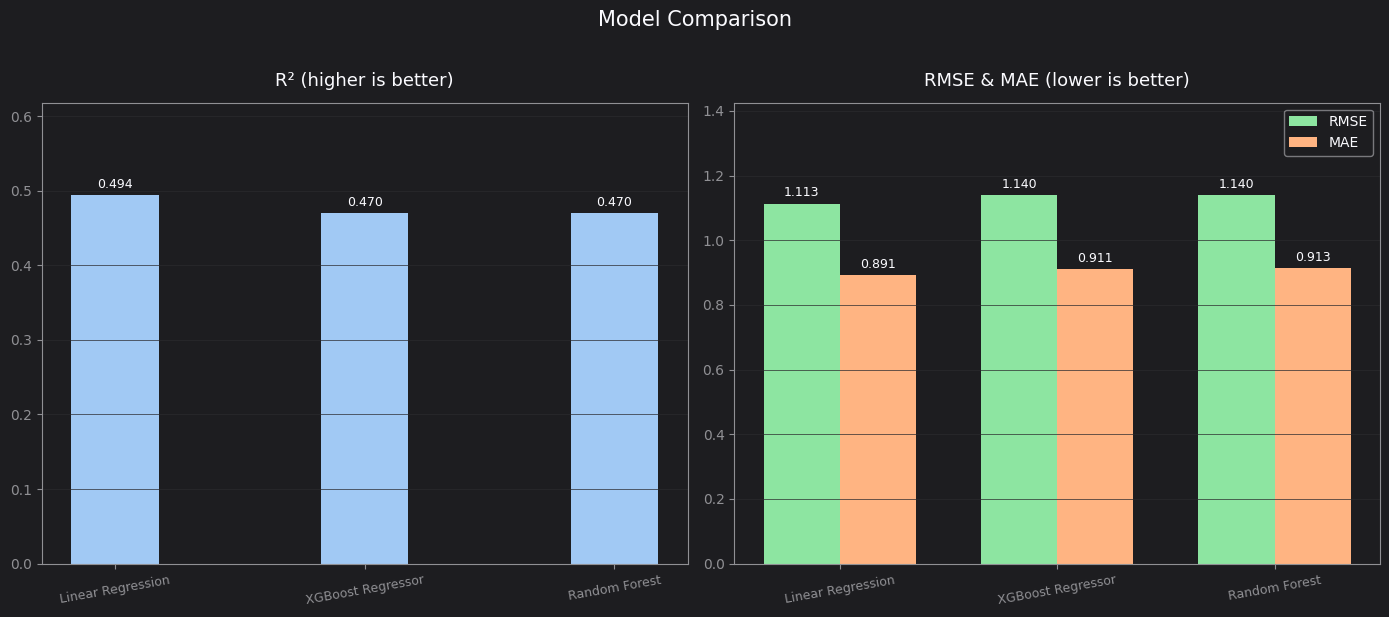

In [177]:
# visual model comparison

models_list = results_df["Model"].tolist()
r2_scores   = results_df["R²"].tolist()
rmse_scores = results_df["RMSE"].tolist()
mae_scores  = results_df["MAE"].tolist()

x = np.arange(len(models_list))
width = 0.35

BG   = "#1D1D20"
TXT  = "#fbfbff"
GRID = "#909094"

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor(BG)

# ---- left panel: R² (higher is better) ----
ax1.set_facecolor(BG)
bars_r2 = ax1.bar(x, r2_scores, width, color="#A1C9F4")

for bar in bars_r2:
    height = bar.get_height()
    ax1.annotate(f"{height:.3f}",
                 xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 3), textcoords="offset points",
                 ha="center", va="bottom", color=TXT, fontsize=9)

ax1.set_title("R² (higher is better)", color=TXT, fontsize=13, pad=12)
ax1.set_xticks(x)
ax1.set_xticklabels(models_list, color=TXT, fontsize=9, rotation=10)
ax1.set_ylim(0, max(r2_scores) * 1.25)
ax1.tick_params(colors=GRID)
ax1.grid(axis="y", color="#2a2a2e", linewidth=0.5)
for spine in ax1.spines.values():
    spine.set_edgecolor(GRID)

# ---- right panel: RMSE & MAE (lower is better) ----
ax2.set_facecolor(BG)
bars_rmse = ax2.bar(x - width/2, rmse_scores, width, label="RMSE", color="#8DE5A1")
bars_mae  = ax2.bar(x + width/2, mae_scores,  width, label="MAE",  color="#FFB482")

for bars in [bars_rmse, bars_mae]:
    for bar in bars:
        height = bar.get_height()
        ax2.annotate(f"{height:.3f}",
                     xy=(bar.get_x() + bar.get_width() / 2, height),
                     xytext=(0, 3), textcoords="offset points",
                     ha="center", va="bottom", color=TXT, fontsize=9)

ax2.set_title("RMSE & MAE (lower is better)", color=TXT, fontsize=13, pad=12)
ax2.set_xticks(x)
ax2.set_xticklabels(models_list, color=TXT, fontsize=9, rotation=10)
ax2.set_ylim(0, max(rmse_scores + mae_scores) * 1.25)
ax2.tick_params(colors=GRID)
ax2.legend(facecolor=BG, labelcolor=TXT, edgecolor=GRID)
ax2.grid(axis="y", color="#2a2a2e", linewidth=0.5)
for spine in ax2.spines.values():
    spine.set_edgecolor(GRID)

fig.suptitle("Model Comparison", color=TXT, fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

=== Model Comparison ===

                      Model     R²   RMSE    MAE
          Linear Regression  0.4943  1.1134  0.8913
          XGBoost Regressor  0.4697  1.1401  0.9110
              Random Forest  0.4696  1.1403  0.9126


**Note:** Linear Regression outperformed both Random Forest and XGBoost.
This suggests the relationship between the features and career readiness
score is largely linear or additive, with limited additional benefit from the nonlinear models tested.

##### SHAP

In [178]:
# get the trained Linear Regression model
linear_model = models["Linear Regression"]

# convert scaled arrays back to DataFrames so SHAP displays feature names
X_train_scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled_df = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)

# use a representative background sample
background = shap.sample(
    X_train_scaled_df,
    100,
    random_state=42
)

# create the SHAP explainer
explainer = shap.LinearExplainer(
    linear_model,
    background
)

# explain a sample of the test data
X_test_shap = shap.sample(
    X_test_scaled_df,
    1000,
    random_state=42
)

shap_values = explainer(X_test_shap)

print("SHAP values created successfully.")

SHAP values created successfully.


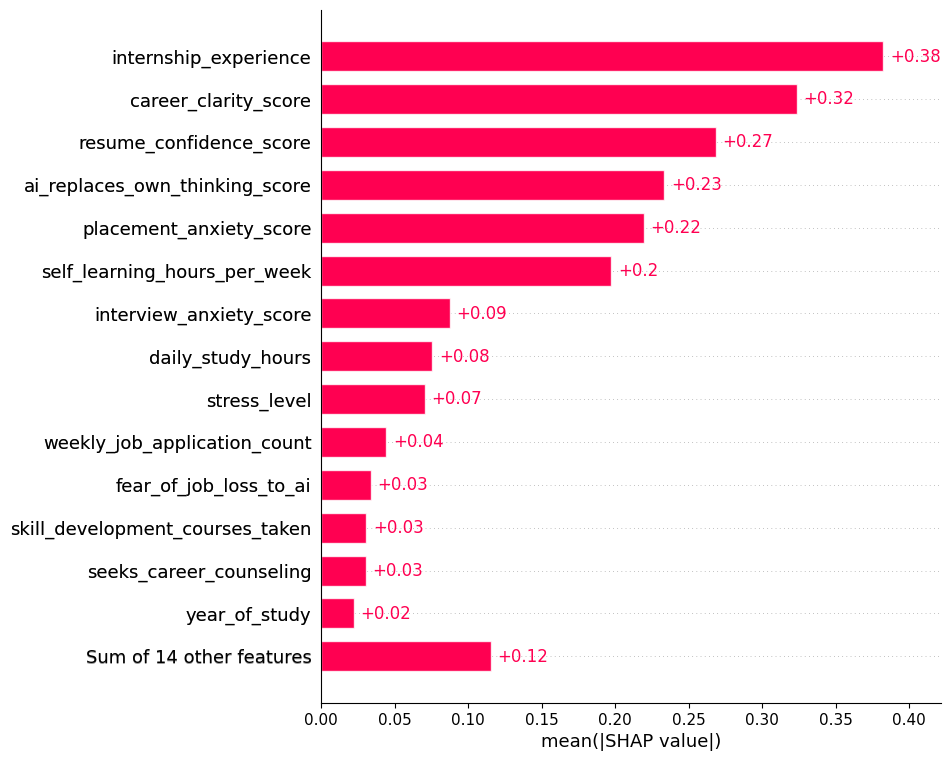

In [179]:
# create the SHAP bar plot
shap.plots.bar(
    shap_values,
    max_display=15
)

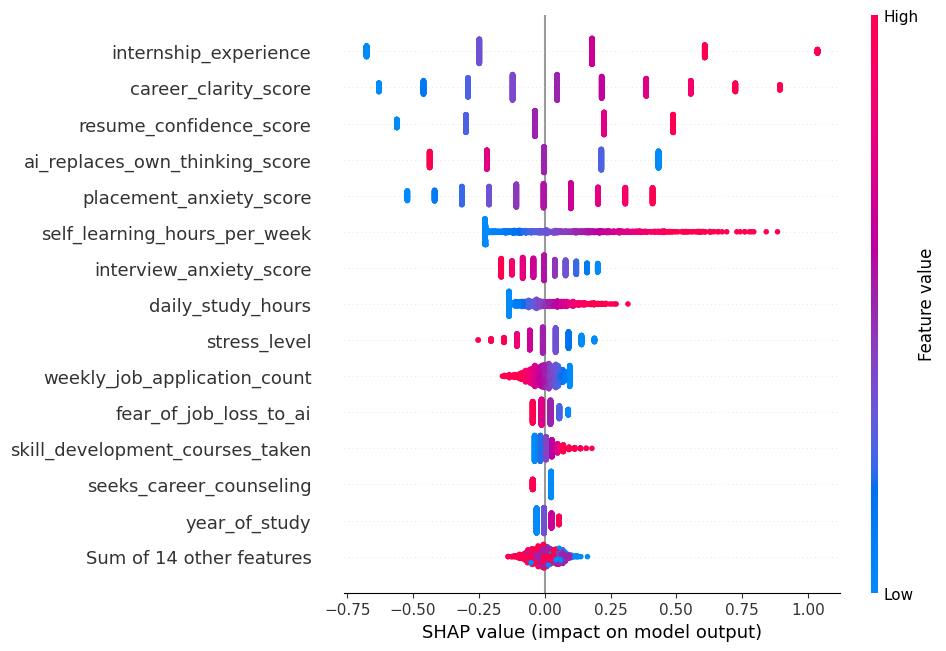

In [180]:
# create the SHAP beeswarm plot
shap.plots.beeswarm(
    shap_values,
    max_display=15
)

### SHAP Interpretation

The SHAP analysis explains how each feature contributed to the predictions
made by the best-performing Linear Regression model.

The bar plot ranks features according to their average absolute SHAP values,
showing which variables had the greatest overall influence on predicted
career readiness. The beeswarm plot additionally shows whether higher or
lower feature values tended to increase or decrease predicted readiness.

Positive SHAP values increase the predicted career-readiness score, while
negative SHAP values decrease it. Because some categorical variables were
label encoded, their SHAP effects should be interpreted cautiously, since
the encoded numbers may introduce an artificial ordering among categories.

CONCLUSION
==========
 
Project Summary
----------------
This project investigated how AI usage, academic habits, psychological
factors, and career-related anxiety relate to overall career readiness
among 15,000 students. After cleaning the data, handling missing values,
and exploring relationships through correlation analysis, three regression
models were trained and compared: Linear Regression, Random Forest, and
XGBoost.
 
Key Findings
------------
1. Linear Regression was the best-performing model (R² = 0.4943), narrowly
   outperforming both ensemble methods. This suggests that the relationships between the measured features and career readiness are largely linear or additive, with limited improvement from the nonlinear models evaluated.

2. The variables most strongly associated with career readiness were:
     - internship_experience (r = 0.56)
     - resume_confidence_score (r = 0.51)
     - daily_study_hours (r = 0.47)
 
3. The strongest negative association with career readiness was observed
   for ai_replaces_own_thinking_score (r = -0.30). Students reporting
   higher scores on this variable tended to report lower career readiness
   scores.
 
4. Model performance (R² ≈ 0.49) indicates that roughly half of the
   variance in career readiness is explained by the measured features.
   The remaining variance is likely driven by factors not captured in
   this dataset, such as personality traits, network/referrals, or
   market conditions.
 
Limitations
-----------
  - R² of ~0.49 leaves substantial unexplained variance; the model should
    not be used for high-stakes individual predictions.
  - LabelEncoder was used for categorical features for simplicity. Because
  integer encoding can create artificial ordering among categories, it
  may have affected model performance, particularly for Linear Regression.
  One-Hot Encoding would provide a more rigorous alternative.

  - No hyperparameter tuning was performed; results reflect default or
    lightly tuned model settings.
 
Future Work
-----------
  - Apply One-Hot Encoding and re-evaluate all models, particularly Linear
  Regression, to determine whether categorical encoding affects performance.
  - Perform hyperparameter tuning (GridSearchCV / RandomizedSearchCV)
    on Random Forest and XGBoost.
  - Test regularized linear models (Ridge, Lasso) to address potential
    multicollinearity (e.g. daily_ai_tool_usage_hrs and ai_dependency_score
    were correlated at r = 0.72).
  - Explore feature engineering, such as combining stress_level and
    burnout_score into a single psychological load index.

Business Recommendations
---------------------------------

Based on the exploratory analysis and predictive modeling, the following recommendations may help improve students' career readiness:

1. Expand internship opportunities.
Internship experience showed the strongest positive association with career readiness. Universities and career centers should encourage students to participate in internships, cooperative education programs, and industry projects early in their academic careers.

2. Strengthen career preparation programs.
Resume confidence and career clarity were positively associated with career readiness. Offering resume workshops, mock interviews, career counseling, and networking events may help students feel better prepared for the job market.

3. Promote productive AI usage.
The results suggest that relying on AI to replace independent thinking was associated with lower career readiness. Educational institutions should encourage students to use AI as a learning assistant rather than a substitute for problem-solving, critical thinking, and skill development.

4. Support student well-being.
Higher levels of interview anxiety, placement anxiety, stress, and burnout were associated with lower career readiness. Providing mental health resources, mentoring programs, and stress management workshops may help improve both student well-being and career preparation.

5. Encourage continuous learning.
Students who reported spending more time studying, completing skill-development courses, and engaging in self-learning generally demonstrated higher career readiness. Universities can support this through professional certifications, workshops, and lifelong learning opportunities.

Final Takeaway
---------------

This project demonstrates a complete end-to-end data science workflow, including data cleaning, exploratory data analysis, feature engineering, predictive modeling, and model evaluation using Python and machine learning techniques. The findings suggest that practical experience, confidence, and consistent learning habits are more strongly associated with career readiness than AI usage alone. While AI can be a valuable educational tool, the results indicate that students benefit most when AI is used to support—not replace—critical thinking and skill development.